[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vittot/ISCB-NLP-Course-2026/blob/main/notebooks/ex1_clustering_exercise.ipynb)

# EX 1 Clustering short clinical texts

**Goal.** We start from short clinical texts with no labels, and we want
to group texts that describe the same clinical condition. We use the `NLP-FBK/dyspnea-clinical-notes` corpus (2667 unlabelled English ED
notes), enriched with diagnosis phrases already extracted from the notes.

## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)

## 2. Build the merged dataset

The extraction step only produced `document_id, diagnosis_phrase`. Here we pull in the
original clinical notes and merge the two, so each row has the raw note text next to its
extracted diagnosis phrase -- useful for spot-checking the extraction, and for later steps
that may want the full note.

**This cell only needs to run once.** It downloads the full notes dataset from Hugging
Face, merges it with the diagnoses, and saves the result to a single CSV. From then on
(and for students), we just load that CSV directly -- no need to redownload or re-merge.

In [2]:
from datasets import load_dataset

notes_ds = load_dataset("NLP-FBK/dyspnea-clinical-notes", split="en")
notes_df = notes_ds.to_pandas()
notes_df["document_id"] = notes_df["document_id"].astype(str)

diagnoses_df = pd.read_csv("data/dyspnea_diagnoses_en.csv", dtype={"document_id": str})

merged = notes_df.merge(diagnoses_df, on="document_id", how="left")
merged.to_csv("data/dyspnea_notes_with_diagnoses.csv", index=False)
print(f"saved {len(merged)} rows -> data/dyspnea_notes_with_diagnoses.csv")

C:\Users\vitto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


saved 2667 rows -> data/dyspnea_notes_with_diagnoses.csv


From here on we just load the merged CSV -- this is what students will start from.

In [3]:
df = pd.read_csv("data/dyspnea_notes_with_diagnoses.csv", dtype={"document_id": str})
print(df.shape)
df.head(10)

(2667, 3)


,clinical_note,document_id,diagnosis_phrase
0,"In ED for abdominal pain localized in LUOGO mesogastric area for about 3 days, non-radiating, stabbing, intermittent...",903116,NaN
1,"TRIAGE: for one week, fever, productive cough, and influenza-like symptoms. At pre-triage T 38.2°C; has not taken an...",1036203,Influenza-like symptoms with fever and productive cough
2,"Patient recently discharged from our ED on 14/11 with diagnosis of portosystemic encephalopathy. Hb 10.\nSince then,...",256860,portosystemic encephalopathy
3,"Recently seen in ED from 1/3 to 2/3/23 for ""ED visit for presyncope with consequent sliding of the knees on the floo...",1195646,permanent AF
4,Fell from approximately 2.5 meters. Brought by MSB without immobilization devices.\n\nReports attempted entry into h...,1804841,bilateral aspiration pneumonia with type 1 respiratory failure
5,Accompanied by MSB.\n\nIn ED for dyspnea and difficulty ambulating for about 15 days.\nAsthenia. No melena.\nHyporex...,869076,lung adenocarcinoma - diagnosis a few years ago - received oral chemotherapy until July 2022 - at CT WB follow-up in...
6,"In ED for onset after lunch of an episode of dizziness, visual blurring, sensation of heat with subsequent presyncop...",715369,presyncope
7,Presents to ED for presyncopal sensation and an episode of vertigo while with a PARENTE. Recent family bereavement; ...,854887,Hypertensive heart disease
8,Patient in ED sent by the treating cardiologist Dr. NOME_PERSONA; unclear reason. Possible lower limb ischemia. Pati...,120579,Ischemic heart disease with hypokinetic evolution
9,Referred to the ED by the Ophthalmic Hospital.\nOn 17/4 episode of loss of consciousness occurred while the patient ...,52473,"fracture of the medial wall and of the medial floor with entrapment of the inferior rectus muscle and, to a lesser d..."


## 3. Exploratory analysis

Before embedding and clustering anything, a few basic questions:
- How many notes had no diagnosis phrase extracted at all?
- How long are the phrases (in characters / words)?
- What do the shortest and longest ones actually look like?
- Are the same phrases repeated across many patients, or is everything unique wording?

### 3.1 Missing values

In [4]:
n_total = len(df)
n_missing = df["diagnosis_phrase"].isna().sum()
print(f"{n_missing} / {n_total} notes ({n_missing / n_total:.1%}) have no extracted diagnosis phrase")

806 / 2667 notes (30.2%) have no extracted diagnosis phrase


### 3.2 Length distribution

Word count matters more than character count for what comes next (embeddings work on
tokens/words, not characters), so we look at both.

Characters:
count    1861.000000
mean       56.872649
std        57.831572
min         2.000000
25%        23.000000
50%        40.000000
75%        70.000000
max       751.000000
Name: diagnosis_phrase, dtype: float64

Words:
count    1861.000000
mean        7.823751
std         8.440882
min         1.000000
25%         3.000000
50%         5.000000
75%        10.000000
max       109.000000
Name: diagnosis_phrase, dtype: float64


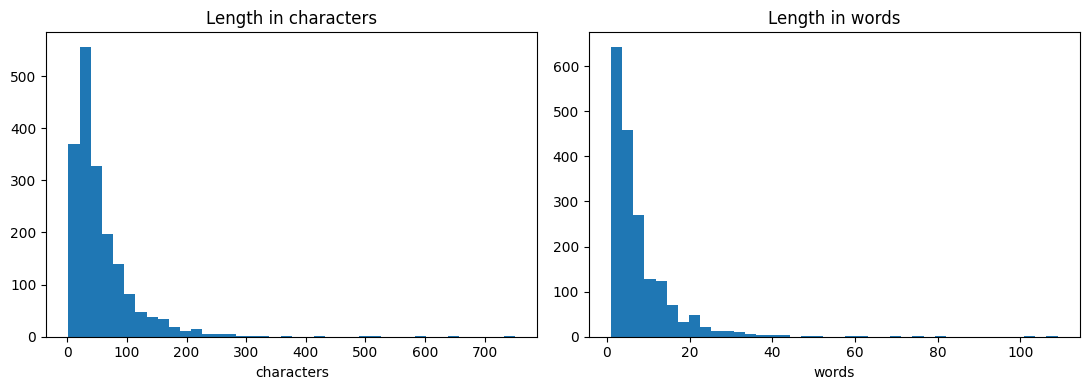

In [5]:
text = df["diagnosis_phrase"].dropna()

lengths_chars = text.str.len()
lengths_words = text.str.split().str.len()

print("Characters:")
print(lengths_chars.describe())
print("\nWords:")
print(lengths_words.describe())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(lengths_chars, bins=40)
axes[0].set_title("Length in characters")
axes[0].set_xlabel("characters")
axes[1].hist(lengths_words, bins=40)
axes[1].set_title("Length in words")
axes[1].set_xlabel("words")
plt.tight_layout()
plt.show()

The distribution has a long tail: most phrases are short (a handful of words), but a few
are much longer -- closer to a clinical excerpt than a short phrase. Worth looking at both
ends directly.

### 3.3 Shortest and longest phrases

In [6]:
print("--- Shortest ---")
for _, row in text.loc[lengths_words.nsmallest(8).index].items():
    print("-", row)

print("\n--- Longest ---")
for _, row in text.loc[lengths_words.nlargest(8).index].items():
    print("-", row[:200] + ("..." if len(row) > 200 else ""))

--- Shortest ---
- presyncope
- Pneumonia
- syncope
- Pneumonia
- NSTEMI
- Diverticulosis
- pneumonia
- syncope

--- Longest ---
- large infrarenal abdominal aortic aneurysm (maximum diameter 73 mm, longitudinal extent approximately 13 cm), an equally large aneurysm of the left common iliac artery (maximum diameter 75 mm, longitu...
- Massive SAH with distribution of blood in the pretruncal cisterns, in the basal cisterns, and in the cistern and fissure NOME_PERSONA on the right. Concomitant intraparenchymal hematoma likely from fi...
- valvular heart disease (replacement of the aortic valve with Epic no.23 biological prosthesis in 2009) --> last echocardiogram in 2021: LV dilated hypertrophic. EF 64, RV dilated normocontractile, bia...
- Left supraciliary laceration-contused wound. Swelling with ecchymosis of the left zygoma. Swelling of the left wrist and abrasions with small superficial wounds on the extensor surface of the PIP join...
- volumetric increase of the large presacral an

The long tail is mostly a handful of notes where the model pulled in an entire clinical
excerpt (imaging findings, treatment history) instead of a short phrase. Something to
watch when we get to embeddings/clustering: these long outliers may behave differently
from the rest and are worth a decision (truncate? keep? re-extract with a stricter length
constraint?) before the next step.

### 3.4 Repeated phrases

In [7]:
top_repeated = text.value_counts()
top_repeated = top_repeated[top_repeated > 1]
print(f"{len(top_repeated)} distinct phrases repeated across more than one note")
top_repeated.head(20)

74 distinct phrases repeated across more than one note


diagnosis_phrase
COVID-19                                      8
acute pulmonary edema                         8
COPD exacerbation                             7
acute coronary syndrome                       6
sepsis                                        6
concussive head trauma                        6
syncope                                       5
head trauma                                   5
acute respiratory distress syndrome (ARDS)    5
hypertensive emergency                        5
Pneumonia                                     4
paroxysmal AF                                 4
pneumonia                                     4
psychomotor agitation                         4
heart failure decompensation                  4
type 1 respiratory failure                    4
non-concussive head trauma                    4
Hypertensive heart disease                    3
severe aortic stenosis                        3
heart failure                                 3
Name: count, dtype: int

Exact repeats are rare, as expected from free text -- most of the clustering signal will
have to come from semantic similarity between *differently worded* mentions of the same
condition (e.g. different phrasings of "pneumonia"), not from exact string matches. That's
exactly the motivation for the embedding + clustering pipeline in the next section.

### 3.5 Reading some raw notes

A few random notes, next to the diagnosis phrase the model extracted from them -- a sanity
check that the extraction is actually picking up something reasonable.

In [8]:
sample = df.sample(5, random_state=0)
for _, row in sample.iterrows():
    print(f"=== {row['document_id']} ===")
    print(row["clinical_note"])
    print(f"--> extracted: {row['diagnosis_phrase']!r}")
    print()

=== 700155 ===
Patient under care, in ED for dyspnea and cough with COPD.
A: airway patent, alert and oriented.
B: reports dyspnea with minimal exertion, SpO2 97% on NC 1 L/min, RR ~20 breaths/min.
C: pulse full and adequate, not tachycardic; skin warm and dry. HR 94, regular; BP 135/80; peripheral IVs in right and left upper limb, 18G. Active spontaneous diuresis.
D: pupils isocoric, isocyclic; GCS 15; Temp 36.6.
E: head-to-toe: nothing to report.
Pain: denies pain.
--> extracted: 'COPD exacerbation'

=== 1583337 ===
In ED for retrosternal chest pain onset during the night at h NUM_TELEFONO.
Intermittent pain, lasting a few seconds (5-10 sec), stabbing in nature, not related to physical exertion.
Pain not increased with palpation, increased with deep inspiration and radiating posteriorly when inhaling.
Denies fever.
Denies cough/dyspnea.
Denies palpitations.
Denies other organ-specific symptoms.
Reports taking paracetamol without benefit.
Denies trauma. Reports physical exertion durin

### 3.6 Notes with no extracted diagnosis

These are the ~30% of notes flagged as missing above. Are they genuinely diagnosis-free
(e.g. a pure vitals/history note), or is the model missing something a human would catch?

In [9]:
missing = df[df["diagnosis_phrase"].isna()]
print(f"{len(missing)} notes with no extracted diagnosis phrase")

sample_missing = missing.sample(5, random_state=0)
for _, row in sample_missing.iterrows():
    print(f"=== {row['document_id']} ===")
    print(row["clinical_note"])
    print()

806 notes with no extracted diagnosis phrase
=== 261156 ===
Brought to the ED by ALS EMS, found by neighbors on the ground in the street after loss of consciousness, with sphincter release and morsus. The patient does not recall the event; recalls the events before the loss of consciousness. Denies dyspnea, chest pain, palpitations. No fever or cough or other COVID-related symptoms.

PARENTE contacted: a neighbor reports having seen the patient collapse to the ground while going up to her home, with loss of consciousness. Placed in lateral position with rapid recovery of consciousness. The PARENTE reports two other episodes of loss of consciousness in the last 6 months, never investigated, without prodrome (one episode while she was seated on the sofa, with the patient suddenly slumping forward and losing consciousness).

Vaccinated against SARS-CoV-2, three doses; last dose administered yesterday (PFIZER).

PMH (from chart): Arterial hypertension
Home meds: antihypertensive, does not 

### 3.7 Is the extraction actually verbatim?

The prompt explicitly asked the model to copy the diagnosis phrase VERBATIM from the note,
not to infer or paraphrase one. Spot-checking by hand turned up at least one clear
counterexample (`acute coronary syndrome` extracted from a note that never uses that
phrase -- the model inferred it from chest pain + rising troponin + history of MI). Let's
quantify how common this is: for every extracted phrase, is it actually a substring of its
source note (case-insensitive)?

In [10]:
has_phrase = df["diagnosis_phrase"].notna()

def is_verbatim(phrase, note):
    return phrase.lower() in note.lower()

verbatim_mask = df.loc[has_phrase].apply(
    lambda r: is_verbatim(r["diagnosis_phrase"], r["clinical_note"]), axis=1
)

n_with_phrase = has_phrase.sum()
n_verbatim = verbatim_mask.sum()
print(
    f"{n_verbatim} / {n_with_phrase} extracted phrases "
    f"({n_verbatim / n_with_phrase:.1%}) appear verbatim (case-insensitive) in their source note"
)

1605 / 1861 extracted phrases (86.2%) appear verbatim (case-insensitive) in their source note


If that percentage is meaningfully below 100%, the model is inferring/paraphrasing
diagnoses in a non-trivial number of cases rather than extracting them -- which matters a
lot for this exercise: the whole point is to cluster *different phrasings that clinicians
actually used*, not diagnoses the model synthesized from its own medical knowledge. A few
non-verbatim examples, to see what that looks like:

In [11]:
non_verbatim = df.loc[has_phrase][~verbatim_mask]
print(f"{len(non_verbatim)} non-verbatim extractions out of {n_with_phrase}\n")

for _, row in non_verbatim.sample(min(5, len(non_verbatim)), random_state=0).iterrows():
    print(f"=== {row['document_id']} ===")
    print(row["clinical_note"][:600])
    print(f"--> extracted (NOT verbatim): {row['diagnosis_phrase']!r}")
    print()

256 non-verbatim extractions out of 1861

=== 754178 ===
A: Airway patent
B: SpO2 80% on RA, RR 30/min, BS with scattered rhonchi over the right anterior field and absent in the left mid-basal area, uses cervical accessory muscles
C: skin warm and diaphoretic, capillary refill ~3 sec, palpable pulse, HR 96 bpm, BP: 70/50 mmHg, heart sounds present, regular
D: Glu 202, stuporous, not arousable to painful stimulus
E: T 39.2, abdomen apparently non-tender, laparotomy scar present on the abdomen, non-palpable purpura predominantly on the right lower extremity
--> extracted (NOT verbatim): 'sepsis'

=== 1211786 ===
Clinical reassessment

BP 90/55 mmHg HR 70 arr
Sat 94% on NC 2 L/min RR 24 breaths/min

Normothermic

Breath sounds present; possible crackles at right base
Arrhythmic; systolic murmur 2/6; no rubs
Abdomen soft, pasto
Bilateral dependent edema; lower extremities dressed

Diuresis over 3 hours - 30 cc/h

Venous blood gas: potassium decreasing - compensated pH - lactate 2
Bedside u

### 3.8 How "messy" is this text compared to ordinary English?

Clinical notes are famously telegraphic and full of abbreviations, jargon and shorthand
(the "nature of clinical language" challenge from block 1). Let's put a number on that,
on the raw `clinical_note` text (not the extracted diagnosis phrases, which are already
fairly clean short phrases). Two angles:

- **Out-of-vocabulary rate**: what fraction of words are rare/unknown to ordinary English?
  (`wordfreq` gives each word's frequency in everyday text; low/zero-frequency words tend
  to be abbreviations, medical jargon, or anonymization placeholders like `NOME_PERSONA`.)
- **Perplexity under a general-English language model** (GPT-2): roughly, how "surprised"
  a model trained on ordinary English is by this text -- this also captures unusual
  grammar and telegraphic style, not just unfamiliar words.


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: C:\Users\vitto\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Clinical notes -- OOV rate (mean): 0.07706158082411907
Ordinary English reference text -- OOV rate: 0.0


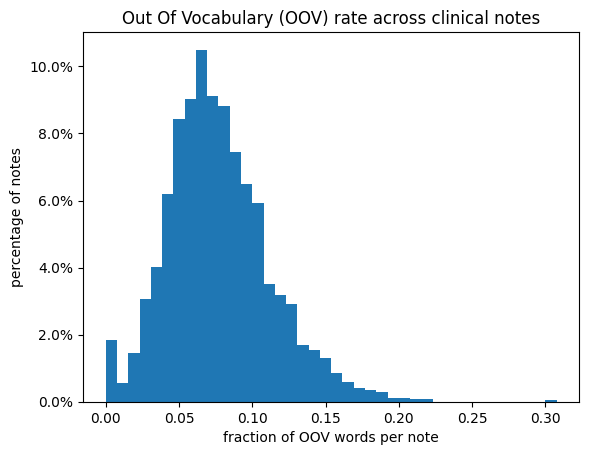

In [62]:
%pip install -q wordfreq
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from wordfreq import zipf_frequency

RARE_THRESHOLD = 2.0  # zipf frequency below this counts as "rare/unknown"

def oov_rate(text, threshold=RARE_THRESHOLD):
    words = re.findall(r"[A-Za-z]+", text)
    if not words:
        return None
    rare = sum(1 for w in words if zipf_frequency(w.lower(), "en") < threshold)
    return rare / len(words)

REFERENCE_TEXT = (
    "The committee met on Tuesday to discuss the annual budget. Members agreed "
    "that spending on public transport should increase next year, while other "
    "departments would need to find savings elsewhere. The proposal will be "
    "reviewed again before the final vote in December."
)

df["oov_rate"] = df["clinical_note"].apply(oov_rate)

print("Clinical notes -- OOV rate (mean):", df["oov_rate"].mean())
print("Ordinary English reference text -- OOV rate:", oov_rate(REFERENCE_TEXT))

values = df["oov_rate"].dropna()
weights = np.ones(len(values)) / len(values)  # each bar shows % of notes

fig, ax = plt.subplots()
ax.hist(values, bins=40, weights=weights)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.xlabel("fraction of OOV words per note")
plt.ylabel("percentage of notes")
plt.title("Out Of Vocabulary (OOV) rate across clinical notes")
plt.show()

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 211.76it/s, Materializing param=transformer.wte.weight]             


Clinical notes (n=200 sample) -- perplexity: mean 137.7, median 126.8
Ordinary English reference text -- perplexity: 23.2


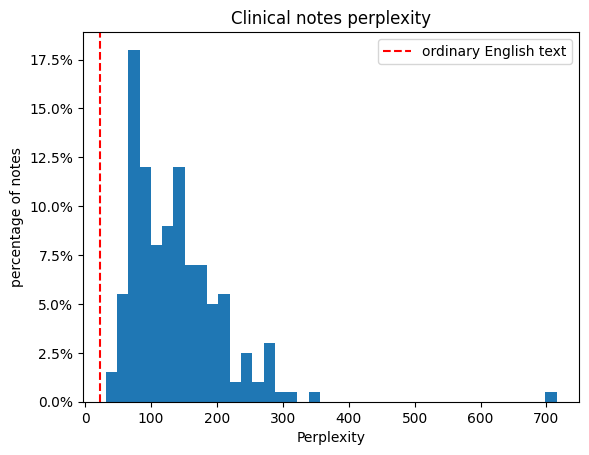

In [66]:
import torch
import numpy as np
from matplotlib.ticker import PercentFormatter
from transformers import AutoTokenizer, AutoModelForCausalLM

device = "cuda" if torch.cuda.is_available() else "cpu"
gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2")
gpt2_model = AutoModelForCausalLM.from_pretrained("gpt2").to(device).eval()

@torch.no_grad()
def perplexity(text, max_length=512):
    enc = gpt2_tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length).to(device)
    if enc["input_ids"].shape[1] < 2:
        return None
    loss = gpt2_model(**enc, labels=enc["input_ids"]).loss
    return torch.exp(loss).item()

# a 200-note sample, for speed -- perplexity is much slower than the OOV rate
sample_notes = df["clinical_note"].sample(200, random_state=0)
sample_ppl = sample_notes.apply(perplexity)

print(f"Clinical notes (n={len(sample_ppl)} sample) -- perplexity: "
      f"mean {sample_ppl.mean():.1f}, median {sample_ppl.median():.1f}")

ref_ppl = perplexity(REFERENCE_TEXT)
print("Ordinary English reference text -- perplexity:", round(ref_ppl, 1))

values = sample_ppl.dropna()
weights = np.ones(len(values)) / len(values)  # each bar shows % of notes

fig, ax = plt.subplots()
ax.hist(values, bins=40, weights=weights)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.axvline(ref_ppl, color="red", linestyle="--", linewidth=1.5,
           label=f"ordinary English text")
ax.legend()
plt.xlabel("Perplexity")
plt.ylabel("percentage of notes")
plt.title("Clinical notes perplexity")
plt.show()

Both metrics point the same way: these notes look far less like "ordinary English" than
the reference paragraph -- a higher OOV rate (abbreviations, jargon, anonymization
placeholders) and much higher perplexity (telegraphic style, missing verbs, unusual word
order). This is exactly the block 1 point about clinical text being harder to work with:
general-purpose language tools are calibrated on text that looks like the reference
paragraph, not this.

## 4. Contextual embeddings with a domain-adapted Transformer

From here on we work on `diagnosis_phrase` (the short extracted phrases), not the full
notes -- that's what we actually want to cluster. Rows with no extracted phrase are
dropped.

We use `pritamdeka/S-PubMedBert-MS-MARCO`: a PubMedBERT encoder fine-tuned specifically to
produce sentence-level embeddings good for semantic similarity/retrieval (unlike a plain
BERT checkpoint, which is not calibrated for that out of the box). It is medical-domain
but literature-trained (PubMed abstracts) rather than clinical-notes-trained -- a
reasonable middle ground given there's no strong English clinical-notes sentence-embedding
model as readily available as BioBERT/ClinicalBERT are for token-level tasks.

In [14]:
%pip install -q sentence-transformers

phrases_df = df.dropna(subset=["diagnosis_phrase"]).reset_index(drop=True)
print(f"{len(phrases_df)} / {len(df)} notes have a diagnosis phrase to embed")

from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("pritamdeka/S-PubMedBert-MS-MARCO")
embeddings = embedder.encode(
    phrases_df["diagnosis_phrase"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True,
)
print(embeddings.shape)


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: C:\Users\vitto\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
1861 / 2667 notes have a diagnosis phrase to embed



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Loading weights:   1%|          | 1/199 [00:00<?, ?it/s, Materializing param=embeddings.LayerNorm.bias]


Loading weights:   1%|          | 1/199 [00:00<?, ?it/s, Materializing param=embeddings.LayerNorm.bias]

...


Batches:  75%|███████▍  | 44/59 [00:01<00:00, 38.24it/s]


Batches:  83%|████████▎ | 49/59 [00:02<00:00, 40.72it/s]


Batches:  92%|█████████▏| 54/59 [00:02<00:00, 43.30it/s]


Batches: 100%|██████████| 59/59 [00:02<00:00, 26.82it/s]

(1861, 768)


Quick sanity check before trusting these embeddings for clustering: do semantically
related phrases actually end up close together, and unrelated ones far apart?

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

probe_idx = phrases_df[
    phrases_df["diagnosis_phrase"].str.contains("pneumonia", case=False, na=False)
].index[:2]
# deliberately pick something clinically unrelated (a fracture) as the contrast case,
# rather than an arbitrary "other" row that might happen to be similar too
unrelated_idx = phrases_df[
    phrases_df["diagnosis_phrase"].str.contains("fracture", case=False, na=False)
].index
other_idx = unrelated_idx[0] if len(unrelated_idx) else phrases_df.index[-1]

if len(probe_idx) == 2:
    a, b, c = probe_idx[0], probe_idx[1], other_idx
    sim_related = cosine_similarity([embeddings[a]], [embeddings[b]])[0, 0]
    sim_unrelated = cosine_similarity([embeddings[a]], [embeddings[c]])[0, 0]
    print(f"{phrases_df['diagnosis_phrase'][a]!r} vs {phrases_df['diagnosis_phrase'][b]!r}: "
          f"cosine similarity = {sim_related:.3f}")
    print(f"{phrases_df['diagnosis_phrase'][a]!r} vs {phrases_df['diagnosis_phrase'][c]!r}: "
          f"cosine similarity = {sim_unrelated:.3f}")

'bilateral aspiration pneumonia with type 1 respiratory failure' vs 'suspected heart failure decompensation and pneumonia': cosine similarity = 0.895
'bilateral aspiration pneumonia with type 1 respiratory failure' vs 'fracture of the medial wall and of the medial floor with entrapment of the inferior rectus muscle and, to a lesser degree, of the ipsilateral medial rectus': cosine similarity = 0.851


Both similarities come out fairly high in absolute terms -- a known quirk of
BERT-derived embeddings (they occupy a narrow, generally-high-cosine-similarity region of
the space, sometimes called representation anisotropy). What matters is the *relative*
ordering: the two pneumonia mentions should still score higher than the unrelated pair,
even if neither number looks close to 0 on its own.

## 5. Dimensionality reduction (PCA)

768 dimensions is a lot relative to ~1800 short phrases, and HDBSCAN (like most
density-based methods) struggles in high dimensions where distances become less
meaningful (the curse of dimensionality). We reduce with PCA, choosing the number of
components from the explained-variance curve rather than picking a number arbitrarily.

122 components explain 90.1% of the variance


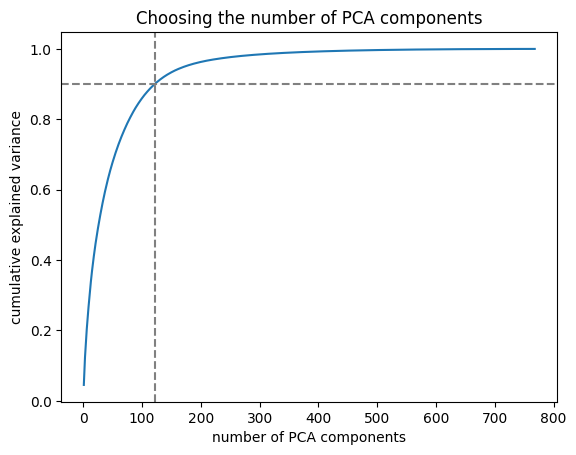

In [16]:
from sklearn.decomposition import PCA

pca_full = PCA(random_state=0).fit(embeddings)
cumvar = pca_full.explained_variance_ratio_.cumsum()

TARGET_VARIANCE = 0.90
n_components = int((cumvar >= TARGET_VARIANCE).argmax()) + 1
print(f"{n_components} components explain {cumvar[n_components - 1]:.1%} of the variance")

plt.plot(range(1, len(cumvar) + 1), cumvar)
plt.axhline(TARGET_VARIANCE, color="grey", linestyle="--")
plt.axvline(n_components, color="grey", linestyle="--")
plt.xlabel("number of PCA components")
plt.ylabel("cumulative explained variance")
plt.title("Choosing the number of PCA components")
plt.show()

In [17]:
pca = PCA(n_components=n_components, random_state=0)
reduced_embeddings = pca.fit_transform(embeddings)
print(reduced_embeddings.shape)

(1861, 122)


## 6. Clustering with HDBSCAN

HDBSCAN's main hyperparameters are `min_cluster_size` (the smallest group of points it
will call a cluster rather than noise) and `min_samples` (how conservative it is about
calling a point noise at all -- scikit-learn's default sets it equal to
`min_cluster_size`, which turns out to be far too conservative here: every
`min_cluster_size` we first tried, with the default, left over 50% of points as noise,
even at the smallest sizes). We sweep both `min_cluster_size` and `min_samples`, scoring
each combination with two things that *are* observable without ground-truth labels: the
noise fraction (points left unassigned, label `-1`) and the silhouette score on the
non-noise points (a rough proxy for how well-separated the clusters are; imperfect for
HDBSCAN's arbitrarily-shaped clusters, but good enough to compare settings against each
other).

In [18]:
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_score

candidate_sizes = [4, 5, 6, 8, 10, 12, 15, 20]
candidate_min_samples = [1, 2, 3]
results = []

for size in candidate_sizes:
    for ms in candidate_min_samples:
        clusterer = HDBSCAN(min_cluster_size=size, min_samples=ms)
        labels = clusterer.fit_predict(reduced_embeddings)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_frac = (labels == -1).mean()

        mask = labels != -1
        if n_clusters >= 2 and mask.sum() >= 2:
            sil = silhouette_score(reduced_embeddings[mask], labels[mask])
        else:
            sil = float("nan")

        results.append({
            "min_cluster_size": size,
            "min_samples": ms,
            "n_clusters": n_clusters,
            "noise_fraction": noise_frac,
            "silhouette": sil,
        })

results_df = pd.DataFrame(results)
results_df.sort_values("noise_fraction").head(15)

,min_cluster_size,min_samples,n_clusters,noise_fraction,silhouette
23,20,3,3,0.438474,0.019185
4,5,2,77,0.516926,0.228103
3,5,1,77,0.516926,0.228103
0,4,1,109,0.523375,0.254187
1,4,2,109,0.523375,0.254187
6,6,1,68,0.531435,0.222495
7,6,2,68,0.531435,0.222495
10,8,2,45,0.587856,0.200788
9,8,1,45,0.587856,0.200788
12,10,1,29,0.605051,0.183959


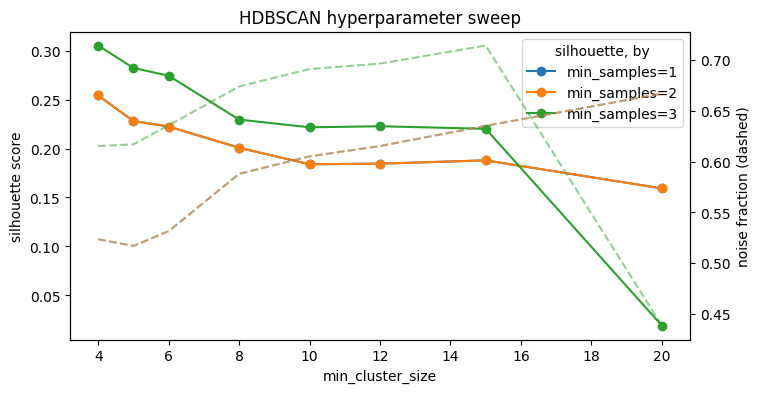

In [19]:
fig, ax1 = plt.subplots(figsize=(8, 4))
for ms, group in results_df.groupby("min_samples"):
    ax1.plot(group["min_cluster_size"], group["silhouette"], "o-", label=f"min_samples={ms}")
ax1.set_xlabel("min_cluster_size")
ax1.set_ylabel("silhouette score")
ax1.legend(title="silhouette, by")

ax2 = ax1.twinx()
for ms, group in results_df.groupby("min_samples"):
    ax2.plot(group["min_cluster_size"], group["noise_fraction"], "--", alpha=0.5)
ax2.set_ylabel("noise fraction (dashed)")

plt.title("HDBSCAN hyperparameter sweep")
plt.show()

Two things stand out. First, noise stays substantial everywhere (40-70%) -- and that's
expected, not a bug: this is exactly the behaviour the course slide on HDBSCAN calls out
("explicitly leaves some noise unassigned"). Many of these ~1800 phrases describe
genuinely unusual, one-off presentations with no close match among the others. Second, and
less expected: the *pure* silhouette-maximiser consistently prefers `min_samples=3` over
1 or 2 at every `min_cluster_size` -- silhouette actually rewards being more conservative
about noise, not less.

That's a problem for what we actually want next: these clusters are meant to become
weak-label categories for a classifier in the next notebook (block 3), and a 60%+ noise
rate throws away most of the phrases before we even get to naming categories, leaving
uncomfortably small classes. So here we deliberately override the pure-silhouette choice:
we accept a modest drop in silhouette in exchange for meaningfully lower noise and larger,
more usable clusters -- a case where blindly optimising an imperfect proxy metric would
work against the actual goal. Concretely: `min_samples=1` or `2` behave identically in
this data (same noise fraction and silhouette at every size, so the choice between them
doesn't matter), and dropping from `min_samples=3` to `2` cuts noise from ~61% to ~52%
while growing the biggest clusters substantially (e.g. the largest one, pleural
effusion/consolidation, goes from 60 to 69 phrases at a comparable cluster count).

In [20]:
MIN_SAMPLES = 2  # deliberately lower than the silhouette-maximiser's choice of 3 -- see above

usable = results_df[(results_df["n_clusters"] >= 5) & (results_df["min_samples"] == MIN_SAMPLES)]
best_row = usable.loc[usable["silhouette"].idxmax()]
best_min_cluster_size = int(best_row["min_cluster_size"])
print("Chosen min_cluster_size:", best_min_cluster_size, "(min_samples fixed at", MIN_SAMPLES, ")")
print(best_row)

final_clusterer = HDBSCAN(min_cluster_size=best_min_cluster_size, min_samples=MIN_SAMPLES)
phrases_df["cluster"] = final_clusterer.fit_predict(reduced_embeddings)

n_clusters_final = phrases_df["cluster"].nunique() - (1 if -1 in phrases_df["cluster"].values else 0)
print(f"{n_clusters_final} clusters, "
      f"{(phrases_df['cluster'] == -1).mean():.1%} of phrases left as noise")

phrases_df["cluster"].value_counts().sort_index()

Chosen min_cluster_size: 4 (min_samples fixed at 2 )
min_cluster_size      4.000000
min_samples           2.000000
n_clusters          109.000000
noise_fraction        0.523375
silhouette            0.254187
Name: 1, dtype: float64


109 clusters, 52.3% of phrases left as noise


cluster
-1      974
 0        9
 1        4
 2        4
 3        4
       ... 
 104      7
 105      4
 106      5
 107     11
 108     11
Name: count, Length: 110, dtype: int64

## 7. Cluster summaries: keywords and examples

For each cluster, a short list of representative keywords (TF-IDF over the cluster's
phrases, so a term that's common inside the cluster but not everywhere scores higher than
a generic word) plus a few example phrases -- enough for a human to recognise the
underlying category without reading every single phrase (this is the manual step that,
in a full pipeline, would feed into mapping clusters onto UMLS concepts or clinical
guideline categories -- not implemented here, but this is exactly the input it would need).

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english", min_df=1)
tfidf = vectorizer.fit_transform(phrases_df["diagnosis_phrase"])
vocab = vectorizer.get_feature_names_out()

def top_keywords(cluster_id, top_n=8):
    mask = (phrases_df["cluster"] == cluster_id).values
    mean_tfidf = tfidf[mask].mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[::-1][:top_n]
    return [vocab[i] for i in top_idx if mean_tfidf[i] > 0]

cluster_sizes = phrases_df["cluster"].value_counts()
top_clusters = cluster_sizes[cluster_sizes.index != -1].sort_values(ascending=False).head(15)

for cluster_id, size in top_clusters.items():
    examples = phrases_df.loc[phrases_df["cluster"] == cluster_id, "diagnosis_phrase"].head(4).tolist()
    print(f"Cluster {cluster_id} (n={size})")
    print("  keywords:", ", ".join(top_keywords(cluster_id)))
    print("  examples:")
    for ex in examples:
        print("   -", ex)
    print()

Cluster 98 (n=69)
  keywords: effusion, pleural, bilateral, basal, interstitial, consolidation, right, syndrome
  examples:
   - right parieto-basal hydropneumothorax with maximum thickness of 8 cm, abundant pleural effusion in the postero-basal region, also consolidation with air bronchogram on the left
   - heart failure with bilateral pleural effusion
   - heart failure with right pleural effusion
   - left pleural effusion with ipsilateral basal consolidation

Cluster 103 (n=45)
  keywords: hypokinetic, cardiomyopathy, dilated, heart, ef, evolution, ischemic, disease
  examples:
   - Ischemic heart disease with hypokinetic evolution
   - decompensation in known dilated hypokinetic cardiomyopathy with normal coronaries
   - hypokinetic cardiomyopathy and right pleural effusion + severe mitral regurgitation
   - Ischemic heart disease with hypokinetic-dilated progression

Cluster 20 (n=35)
  keywords: lung, adenocarcinoma, pulmonary, cancer, neoplasm, metastases, carcinoma, adrenal
 

### 7.1 Word clouds for the largest clusters

Same TF-IDF weights as above, just as word clouds instead of a plain list -- word size
reflects how distinctive/frequent that term is within the cluster. Only the 6 largest
clusters, to keep this readable.


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: C:\Users\vitto\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


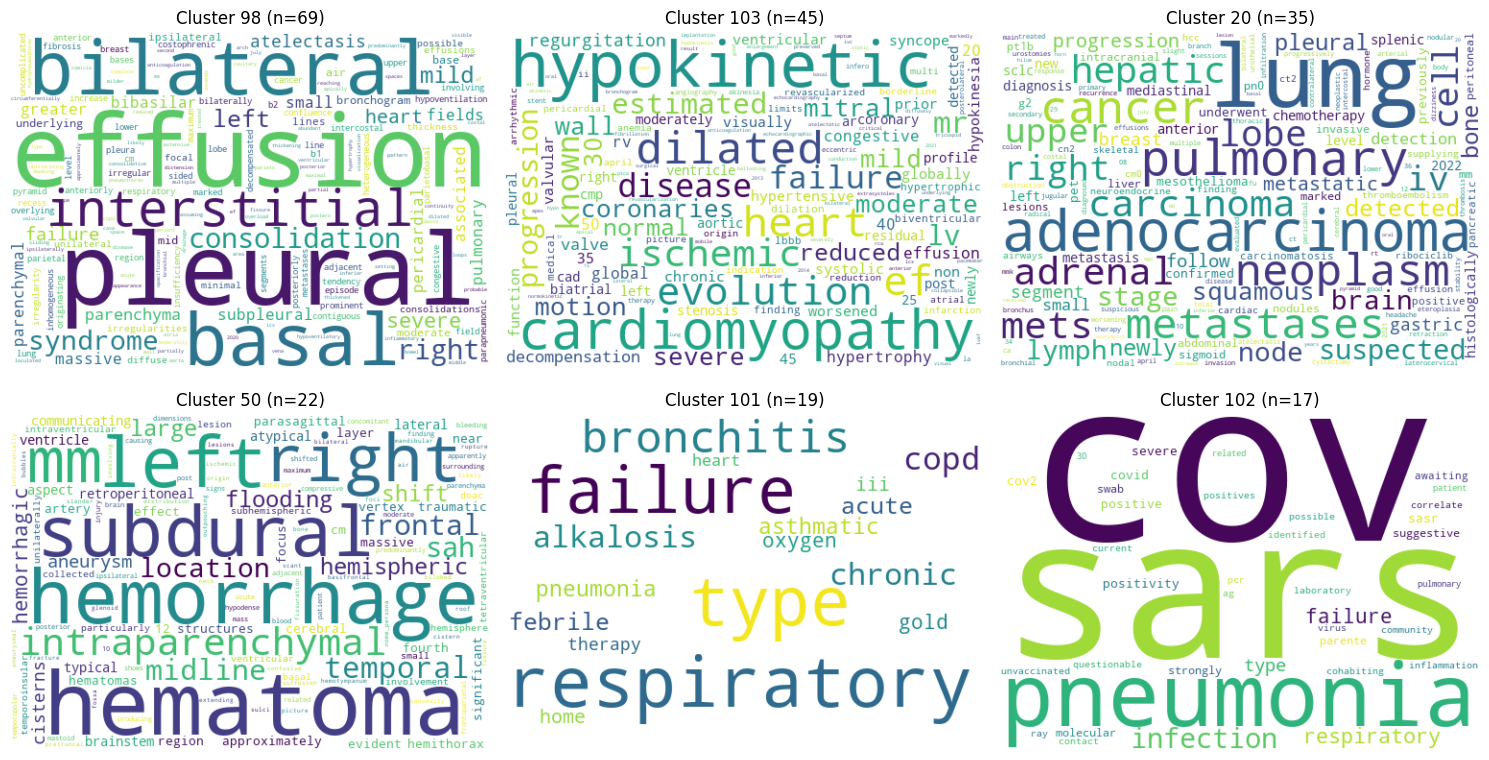

In [22]:
%pip install -q wordcloud
from wordcloud import WordCloud

def cluster_tfidf_weights(cluster_id):
    mask = (phrases_df["cluster"] == cluster_id).values
    mean_tfidf = tfidf[mask].mean(axis=0).A1
    return {vocab[i]: mean_tfidf[i] for i in range(len(vocab)) if mean_tfidf[i] > 0}

top6 = top_clusters.head(6)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (cluster_id, size) in zip(axes.flat, top6.items()):
    weights = cluster_tfidf_weights(cluster_id)
    wc = WordCloud(width=500, height=350, background_color="white").generate_from_frequencies(weights)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"Cluster {cluster_id} (n={size})")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Baseline: would a simpler method (LDA) do just as well?

Before trusting that embeddings + HDBSCAN is worth its complexity, it's worth checking
against something much simpler: fit a classic topic model (Latent Dirichlet Allocation)
directly on bag-of-words counts of the same phrases, and see whether its topics group
things at least as sensibly.

In [23]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

N_TOPICS = 20  # same order of magnitude as a coarse clustering; LDA needs decent
               # word co-occurrence per topic, so more topics gets unstable on ~1800
               # short phrases with a small, sparse vocabulary

count_vectorizer = CountVectorizer(stop_words="english", min_df=2)
bow = count_vectorizer.fit_transform(phrases_df["diagnosis_phrase"])

lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=0, learning_method="batch")
topic_distributions = lda.fit_transform(bow)
phrases_df["lda_topic"] = topic_distributions.argmax(axis=1)  # hard-assign to the most likely topic

phrases_df["lda_topic"].value_counts().sort_index()

lda_topic
0      98
1     113
2      91
3      79
4      77
5     151
6      99
7      90
8      85
9      47
10     69
11    128
12     96
13    125
14     82
15     81
16     61
17     70
18     99
19    120
Name: count, dtype: int64

LDA has no notion of "noise": every phrase gets assigned to its most likely topic no
matter how weak the signal, unlike HDBSCAN, which explicitly refused to assign ~62% of
phrases to anything. For a fair comparison we score both on the *same* subset of phrases
(the ones HDBSCAN did assign to a cluster) and in the *same* representation (the
PCA-reduced PubMedBERT embedding space) -- so any difference in the score comes from the
clustering/topic assignment itself, not from different data or a different space. We also
report LDA's score on all phrases, since covering all of them (not discarding ~62% as
noise) is arguably part of what "simpler" buys you, for better or worse.

In [24]:
non_noise_mask = (phrases_df["cluster"] != -1).values

sil_hdbscan = silhouette_score(reduced_embeddings[non_noise_mask], phrases_df.loc[non_noise_mask, "cluster"])
sil_lda_same_subset = silhouette_score(reduced_embeddings[non_noise_mask], phrases_df.loc[non_noise_mask, "lda_topic"])
sil_lda_all = silhouette_score(reduced_embeddings, phrases_df["lda_topic"])

print(f"HDBSCAN on embeddings, non-noise phrases only:  silhouette = {sil_hdbscan:.3f}")
print(f"LDA ({N_TOPICS} topics), same phrases:                silhouette = {sil_lda_same_subset:.3f}")
print(f"LDA ({N_TOPICS} topics), all phrases (no noise concept): silhouette = {sil_lda_all:.3f}")

HDBSCAN on embeddings, non-noise phrases only:  silhouette = 0.254
LDA (20 topics), same phrases:                silhouette = 0.022
LDA (20 topics), all phrases (no noise concept): silhouette = -0.003


Silhouette scores each clustering against a shared yardstick (the embedding space),
but it doesn't say how much the two partitions actually *agree* with each other on which
phrases belong together. For that we need a partition-agreement
metric: the **Adjusted Rand Index** (ARI) counts how often two clusterings agree on
whether a *pair* of points are in the same group or not, corrected for the agreement
you'd expect by pure chance -- 1.0 means identical partitions, 0.0 means no better than a
random relabelling. **Adjusted Mutual Information** (AMI) asks the same "how much do
these two partitions agree" question from an information-theoretic angle instead, and
tends to be less sensitive to very different numbers of clusters (86 HDBSCAN clusters vs
20 LDA topics here) -- worth reporting alongside ARI rather than instead of it, since they
occasionally disagree in how much credit to give a partial match. Computed on the phrases
HDBSCAN actually assigned to a cluster (dropping noise, since LDA has nothing to compare
against there).

In [25]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

ari_lda = adjusted_rand_score(
    phrases_df.loc[non_noise_mask, "cluster"], phrases_df.loc[non_noise_mask, "lda_topic"]
)
ami_lda = adjusted_mutual_info_score(
    phrases_df.loc[non_noise_mask, "cluster"], phrases_df.loc[non_noise_mask, "lda_topic"]
)
print(f"HDBSCAN clusters vs LDA topics, non-noise phrases (n={non_noise_mask.sum()}):")
print(f"  Adjusted Rand Index:        {ari_lda:.3f}")
print(f"  Adjusted Mutual Information: {ami_lda:.3f}")

HDBSCAN clusters vs LDA topics, non-noise phrases (n=887):
  Adjusted Rand Index:        0.168
  Adjusted Mutual Information: 0.406


A qualitative look, the same way we inspected HDBSCAN clusters in section 7:

In [26]:
vocab_bow = count_vectorizer.get_feature_names_out()

def lda_top_words(topic_idx, top_n=8):
    weights = lda.components_[topic_idx]
    top_idx = weights.argsort()[::-1][:top_n]
    return [vocab_bow[i] for i in top_idx]

topic_sizes = phrases_df["lda_topic"].value_counts().sort_values(ascending=False)
for topic_idx, size in topic_sizes.head(5).items():
    examples = phrases_df.loc[phrases_df["lda_topic"] == topic_idx, "diagnosis_phrase"].head(4).tolist()
    print(f"Topic {topic_idx} (n={size})")
    print("  top words:", ", ".join(lda_top_words(topic_idx)))
    print("  examples:")
    for ex in examples:
        print("   -", ex)
    print()

Topic 5 (n=151)
  top words: left, right, pain, limb, lower, fracture, hemithorax, wound
  examples:
   - left hemithorax pain
   - lacerated-contused wound of the eyelid margin
   - cramp-like pain in the hypogastric, midline prepubic area, radiating to the R testicle
   - suspected pulmonary metastasis, left upper lobe

Topic 11 (n=128)
  top words: heart, failure, disease, aortic, valvular, hypertensive, severe, mitral
  examples:
   - Hypertensive heart disease
   - decompensated congestive heart failure and sepsis
   - suspected heart failure decompensation and pneumonia
   - mild aortic stenosis in hypertensive heart disease

Topic 13 (n=125)
  top words: suspected, pneumonia, covid, sepsis, urinary, tract, 19, infection
  examples:
   - Pneumonia
   - urinary tract infection
   - Pneumonia
   - Critical bilateral ICA stenosis: left ICA 85% and left ECA 65% - right ICA 25%

Topic 19 (n=120)
  top words: pleural, effusion, right, basal, left, ischemic, stroke, consolidation
  exam

Same idea as a word cloud, using LDA's own topic-word weights this time (not TF-IDF):

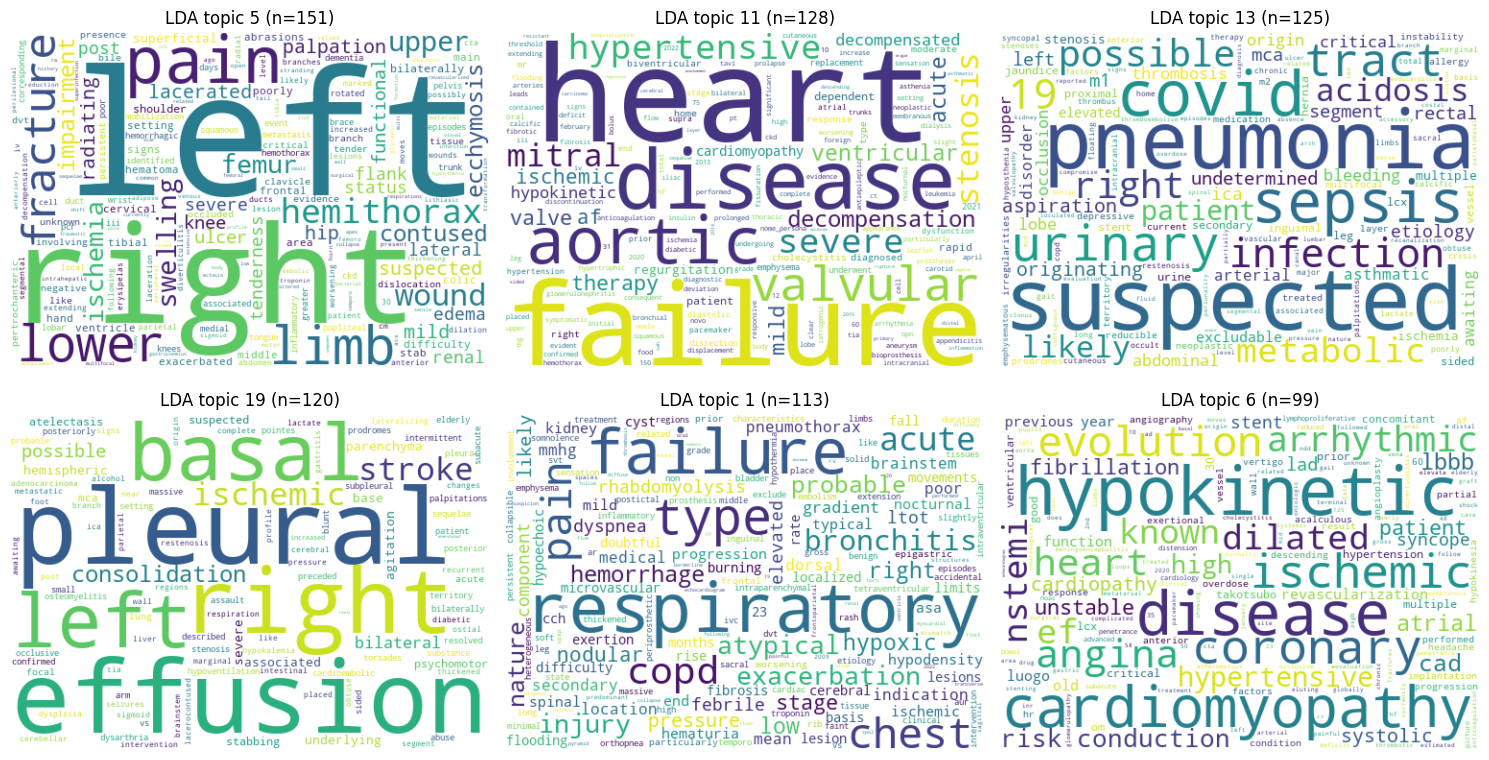

In [27]:
def lda_topic_weights(topic_idx):
    weights = lda.components_[topic_idx]
    return {vocab_bow[i]: weights[i] for i in range(len(vocab_bow)) if weights[i] > 0}

top6_topics = topic_sizes.head(6)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (topic_idx, size) in zip(axes.flat, top6_topics.items()):
    wc = WordCloud(width=500, height=350, background_color="white").generate_from_frequencies(lda_topic_weights(topic_idx))
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"LDA topic {topic_idx} (n={size})")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 9. Saving outputs for the next notebook

Two things to carry forward into the weak-supervision/classification notebook (block 3):

1. The notes with their cluster assignment (the HDBSCAN clustering from section 6, not the
   LDA or ClinicalBERT baselines from section 8/appendix) -- saved to a *new* file, not
   overwriting `dyspnea_notes_with_diagnoses.csv` from section 2.
2. A per-cluster summary (size, keywords, a few example phrases) -- this is what we'll use
   to decide, by hand, which clusters are clean and large enough to turn into weak-label
   categories (following the bronchiolitis case study approach: pick a couple of
   well-defined clusters as target classes, rather than trying to use all 86).

In [28]:
output_cols = ["document_id", "clinical_note", "diagnosis_phrase", "cluster"]
phrases_df[output_cols].to_csv("data/dyspnea_notes_with_clusters.csv", index=False)
print(f"saved {len(phrases_df)} rows -> data/dyspnea_notes_with_clusters.csv")

saved 1861 rows -> data/dyspnea_notes_with_clusters.csv


In [29]:
def cluster_summary_row(cluster_id):
    mask = phrases_df["cluster"] == cluster_id
    examples = phrases_df.loc[mask, "diagnosis_phrase"].head(3).tolist()
    return {
        "cluster": cluster_id,
        "size": int(mask.sum()),
        "keywords": ", ".join(top_keywords(cluster_id)),
        "examples": " | ".join(examples),
    }

cluster_ids = sorted(c for c in phrases_df["cluster"].unique() if c != -1)
clusters_summary_df = pd.DataFrame([cluster_summary_row(c) for c in cluster_ids])
clusters_summary_df = clusters_summary_df.sort_values("size", ascending=False).reset_index(drop=True)

clusters_summary_df.to_csv("data/dyspnea_cluster_summaries.csv", index=False)
print(f"saved {len(clusters_summary_df)} cluster summaries -> data/dyspnea_cluster_summaries.csv "
      f"({int((phrases_df['cluster'] == -1).sum())} phrases left as noise, not included)")

clusters_summary_df.head(10)

saved 109 cluster summaries -> data/dyspnea_cluster_summaries.csv (974 phrases left as noise, not included)


,cluster,size,keywords,examples
0,98,69,"effusion, pleural, bilateral, basal, interstitial, consolidation, right, syndrome","right parieto-basal hydropneumothorax with maximum thickness of 8 cm, abundant pleural effusion in the postero-basal..."
1,103,45,"hypokinetic, cardiomyopathy, dilated, heart, ef, evolution, ischemic, disease",Ischemic heart disease with hypokinetic evolution | decompensation in known dilated hypokinetic cardiomyopathy with ...
2,20,35,"lung, adenocarcinoma, pulmonary, cancer, neoplasm, metastases, carcinoma, adrenal",lung adenocarcinoma - diagnosis a few years ago - received oral chemotherapy until July 2022 - at CT WB follow-up in...
3,50,22,"hematoma, hemorrhage, subdural, left, right, mm, intraparenchymal, temporal",hematoma on the lateral aspect of the left hemithorax | left hemispheric subdural hematoma of approximately 12 mm ca...
4,101,19,"respiratory, type, failure, bronchitis, copd, chronic, alkalosis, acute","respiratory failure in heart failure and acute asthmatic bronchitis | COPD GOLD III, with Type 2 respiratory failure..."
5,102,17,"cov, sars, pneumonia, infection, respiratory, failure, type, positivity",SARS-CoV-2 infection | SARS-CoV-2 positivity | SARS-CoV-2 positive
6,54,13,"episode, presyncopal, syncopal, presyncope, syncope, head, probable, trauma",presyncope | postprandial presyncopal episode | suspected syncopal episode
7,57,13,"hypotension, orthostatic, presyncope, hypotensive, likely, syncope, origin, loc",orthostatic hypotension and aortic valve stenosis | likely situational syncope due to orthostatic hypotension | prob...
8,18,12,"pacemaker, av, block, iatrogenic, implantation, indication, degree, dddr",DDD pacemaker for syncope and paroxysmal blocks | dual-chamber pacemaker for first-degree AV block with episodes of ...
9,90,12,"exacerbation, copd, acute, respiratory, asthma, failure, fever, hypoxic",COPD exacerbation | COPD exacerbation | COPD exacerbation


## Appendix: does the embedding model choice matter?

We picked `S-PubMedBert-MS-MARCO` over a plain domain-matched model like ClinicalBERT
because it is explicitly fine-tuned for semantic similarity/retrieval, not just
pretrained on medical text -- but that was an argument, not evidence. Let's check it by
running the *same* PCA -> HDBSCAN pipeline on `emilyalsentzer/Bio_ClinicalBERT`
(mean-pooled last-hidden-state embeddings -- ClinicalBERT has no sentence-embedding head
of its own) over the same phrases, and comparing.

Parked here as an appendix rather than in the main flow -- interesting to know, but not
essential to the exercise, and there may not be time to cover it live.

**Caveat before looking at numbers**: the comparison below leans on the silhouette score,
which is a rough proxy at best for a HDBSCAN clustering -- it assumes roughly convex,
well-separated clusters, which is precisely what HDBSCAN does *not* try to produce (it is
built to find clusters of arbitrary shape and density). The more appropriate density-aware
metric is HDBSCAN's own DBCV-style validity index, available in the standalone `hdbscan`
package but not exposed by scikit-learn's implementation -- skipped here to avoid an extra
dependency. So: read this as a signal for comparing two settings against each other, not
as a validated absolute score. The keyword/example inspection from section 7 remains the
more trustworthy check of whether a clustering is actually any good.

In [30]:
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel

def mean_pooled_embeddings(model_name, texts, batch_size=32):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device).eval()

    all_embeddings = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i : i + batch_size]
            enc = tokenizer(batch, padding=True, truncation=True, return_tensors="pt").to(device)
            hidden = model(**enc).last_hidden_state
            mask = enc["attention_mask"].unsqueeze(-1).float()
            summed = (hidden * mask).sum(1)
            counts = mask.sum(1).clamp(min=1e-9)
            all_embeddings.append((summed / counts).cpu().numpy())

    emb = np.vstack(all_embeddings)
    return emb / np.linalg.norm(emb, axis=1, keepdims=True)  # normalize, same as the PubMedBERT embeddings

clinicalbert_embeddings = mean_pooled_embeddings(
    "emilyalsentzer/Bio_ClinicalBERT", phrases_df["diagnosis_phrase"].tolist()
)
print(clinicalbert_embeddings.shape)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Loading weights:   1%|          | 1/199 [00:00<?, ?it/s, Materializing param=embeddings.LayerNorm.bias]


Loading weights:   1%|          | 1/199 [00:00<?, ?it/s, Materializing param=embeddings.LayerNorm.bias]


Loading weights:   1%|          | 2/199 [00:00<?, ?it/s, Materializing param=embeddings.LayerNorm.weight]


Loading weights:   1%|          | 2/199 [00:00<?, ?it/s, Materializing param=embeddings.LayerNorm.weight]

...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 846.19it/s, Materializing param=pooler.dense.weight]


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 846.19it/s, Materializing param=pooler.dense.weight]


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 890.21it/s, Materializing param=pooler.dense.weight]


BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(1861, 768)


In [31]:
def run_pca_hdbscan(emb, target_variance=0.90, min_samples=2, candidate_sizes=(4, 5, 6, 8, 10, 12, 15, 20)):
    # min_samples=2, not scikit-learn's more conservative default -- kept in sync with the
    # deliberate noise/coverage trade-off made in section 6, not a fresh silhouette-only pick.
    pca_full = PCA(random_state=0).fit(emb)
    cumvar = pca_full.explained_variance_ratio_.cumsum()
    n_comp = int((cumvar >= target_variance).argmax()) + 1
    reduced = PCA(n_components=n_comp, random_state=0).fit_transform(emb)

    rows = []
    for size in candidate_sizes:
        labels = HDBSCAN(min_cluster_size=size, min_samples=min_samples).fit_predict(reduced)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_frac = (labels == -1).mean()
        mask = labels != -1
        sil = (
            silhouette_score(reduced[mask], labels[mask])
            if n_clusters >= 2 and mask.sum() >= 2
            else float("nan")
        )
        rows.append({"min_cluster_size": size, "n_clusters": n_clusters, "noise_fraction": noise_frac, "silhouette": sil})

    sweep = pd.DataFrame(rows)
    usable = sweep[sweep["n_clusters"] >= 5]
    if usable["silhouette"].notna().any():
        best = usable.loc[usable["silhouette"].idxmax()]
    else:
        best = sweep.iloc[-1]

    final_labels = HDBSCAN(min_cluster_size=int(best["min_cluster_size"]), min_samples=min_samples).fit_predict(reduced)
    return {
        "n_pca_components": n_comp,
        "min_cluster_size": int(best["min_cluster_size"]),
        "n_clusters": int(best["n_clusters"]),
        "noise_fraction": float(best["noise_fraction"]),
        "silhouette": float(best["silhouette"]),
        "labels": final_labels,
    }

pubmedbert_result = run_pca_hdbscan(embeddings)
clinicalbert_result = run_pca_hdbscan(clinicalbert_embeddings)

comparison = pd.DataFrame(
    [
        {"model": "S-PubMedBert-MS-MARCO", **{k: v for k, v in pubmedbert_result.items() if k != "labels"}},
        {"model": "Bio_ClinicalBERT (mean-pooled)", **{k: v for k, v in clinicalbert_result.items() if k != "labels"}},
    ]
).set_index("model")
comparison

,n_pca_components,min_cluster_size,n_clusters,noise_fraction,silhouette
model,,,,,
S-PubMedBert-MS-MARCO,122,4,109,0.523375,0.254187
Bio_ClinicalBERT (mean-pooled),120,6,71,0.610425,0.275078


If the two rows land close together, that's itself informative: it would suggest the
embedding model matters less than expected here (perhaps because the phrases are short
enough, or specific enough vocabulary-wise, that either model separates them reasonably),
and the earlier argument for PubMedBERT was more theoretical than practically decisive for
this particular dataset. If ClinicalBERT does noticeably worse (lower silhouette, and/or a
much higher noise fraction for a comparable number of clusters), that's evidence -- albeit
of the same rough kind discussed above -- for the sentence-similarity fine-tuning
argument.

As in section 8, the silhouette scores above don't say how much the two clusterings
actually *agree* on grouping the same phrases together -- for that, ARI and AMI again,
this time restricted to phrases that got assigned to an actual cluster (not noise) by
*both* embeddings, since each ran its own independent HDBSCAN sweep and can leave
different phrases as noise.

In [32]:
clinicalbert_labels = pd.Series(clinicalbert_result["labels"], index=phrases_df.index)
both_assigned = (phrases_df["cluster"] != -1).values & (clinicalbert_labels != -1).values

ari_emb = adjusted_rand_score(
    phrases_df.loc[both_assigned, "cluster"], clinicalbert_labels.loc[both_assigned]
)
ami_emb = adjusted_mutual_info_score(
    phrases_df.loc[both_assigned, "cluster"], clinicalbert_labels.loc[both_assigned]
)
print(f"PubMedBERT clusters vs ClinicalBERT clusters, phrases assigned by both (n={both_assigned.sum()}):")
print(f"  Adjusted Rand Index:        {ari_emb:.3f}")
print(f"  Adjusted Mutual Information: {ami_emb:.3f}")

PubMedBERT clusters vs ClinicalBERT clusters, phrases assigned by both (n=509):
  Adjusted Rand Index:        0.604
  Adjusted Mutual Information: 0.806


Word clouds for the largest ClinicalBERT clusters, using the same TF-IDF weights as
section 7 (TF-IDF is computed on the phrases' text, so it's independent of which
embedding model produced the clustering -- only the cluster assignment below is
ClinicalBERT's).

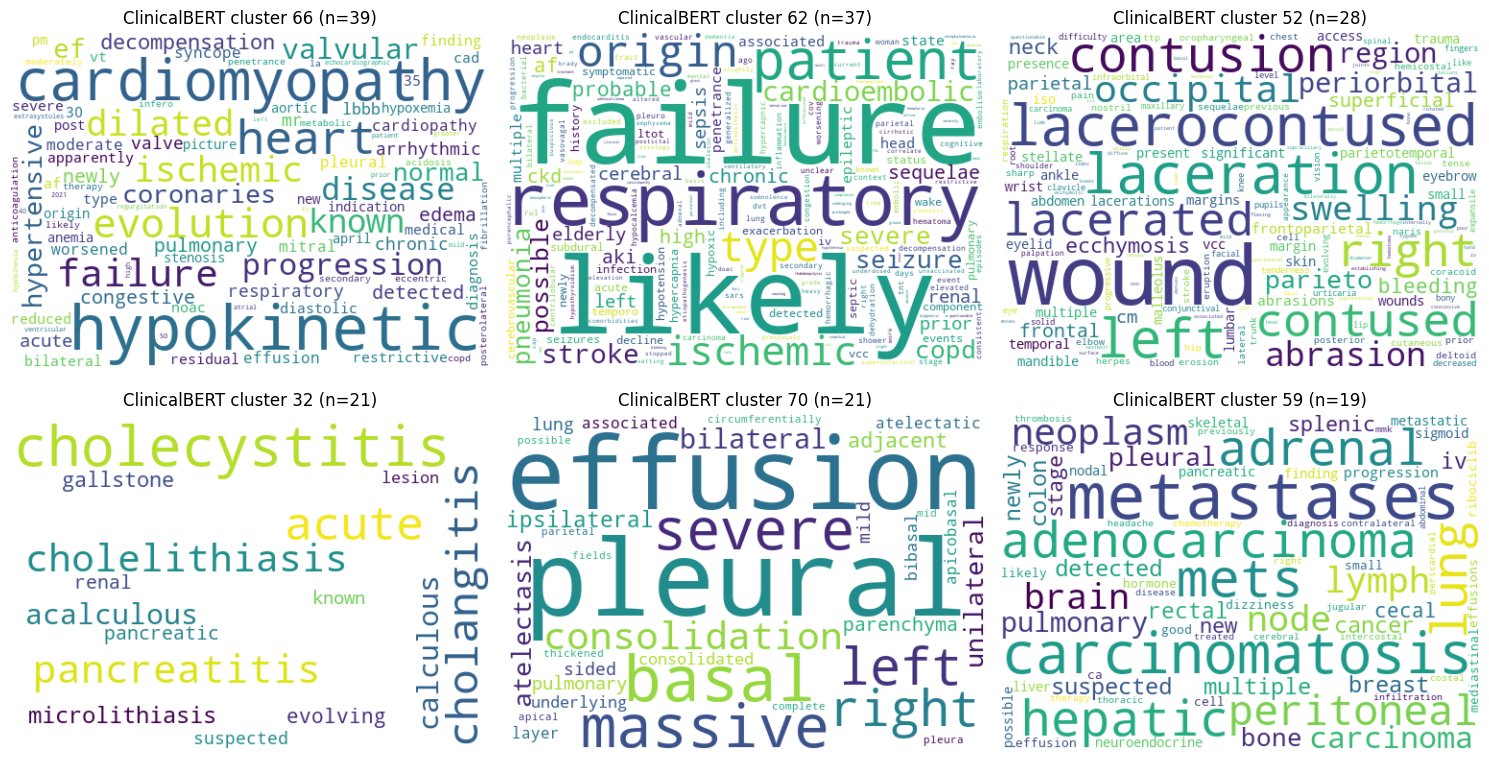

In [33]:
def clinicalbert_cluster_weights(cluster_id):
    mask = (clinicalbert_labels == cluster_id).values
    mean_tfidf = tfidf[mask].mean(axis=0).A1
    return {vocab[i]: mean_tfidf[i] for i in range(len(vocab)) if mean_tfidf[i] > 0}

clinicalbert_sizes = clinicalbert_labels.value_counts()
clinicalbert_top6 = clinicalbert_sizes[clinicalbert_sizes.index != -1].sort_values(ascending=False).head(6)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (cluster_id, size) in zip(axes.flat, clinicalbert_top6.items()):
    wc = WordCloud(width=500, height=350, background_color="white").generate_from_frequencies(
        clinicalbert_cluster_weights(cluster_id)
    )
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"ClinicalBERT cluster {cluster_id} (n={size})")
    ax.axis("off")
plt.tight_layout()
plt.show()